# 1. 理解Agents

通用人工智能（AGI）将是 AI的终极形态 ，几乎已成为业界共识。同样，构建智能体（Agent）则是AI工程应用 当下的“终极形态” ，即Agent是大模型应用开发的核心。

## 1.1 什么是Agent？

在大模型应用开发中，智能体通常指一种以 大语言模型为推理与决策核心 ，结合 记忆 、 工具调用 与
环境交互能力，能够进行 规划决策 并执行 复杂任务 以达成目标的软件系统。

Agent的关键能力
* 理解用户问题
* 如何 拆解任务
* 判断 是否需要工具
* 需要 调用哪些工具
* 如何利用好 工具结果 生成回答&推进任务

## 1.2 核心组件
前面讲过现在AI Agent的架构：

实际开发中几个要素并不需要同时出现，一句话总结
1. 必须的：行动（Action）
2. 几乎总是存在的：工具（Tool）
3. 有条件存在的：规划决策（Planning）
4. 最容易被省略的：记忆（Memory

## 1.3 Agent创建与调用

在 LangChain 0.x 时代，框架内的 Agent 系统经历了“碎片化”阶段。当时的设计理念是 “针对场景设计特定 Agent”：
1. 如果你要实现思维链推理（ReAct），就用 create_react_agent ；
2. 如果需要结构化输出，就用 create_structured_chat_agent ；
3. 要工具调用，则用 create_tool_calling_agent 。

LangChain 在 1.0 版本后，团队做出了彻底重构：将所有 Agent 的创建方式统一为一个入口：create_agent()。它取代了旧版本中的 create_react_agent 、 create_json_agent 、create_tool_calling_agent 等多种分支函数，真正让开发者用一行代码即可创建任何类型的智能体。

同时在底层通过“中间件机制（Middleware）”和“标准模型接口（invoke / stream）”实现全局统一。这让框架更轻、更稳，也更易于被集成到其他 Agent 平台中。

```python
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

import os
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv

load_dotenv(override=True, verbose=True,dotenv_path="conf/.env")

# Initialize the chat model
model = init_chat_model(
    model="gpt-6-luna",
    model_provider="openai",
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_API_BASE"),
)
# 2. 创建 Agent
agent = create_agent(
    model=model,
    tools=[tool1, tool2, tool3],  # Replace with your actual tools
    system_prompt="Agent 的行为指令" # 可选
)

# 3. 调用
result = agent.invoke({
    "messages": [{"role": "user", "content": "问题"}]
})
```

# 2. Agent的基本用法1：模型的传入方式

在 LangChain 1.4 中， create_agent 是构建智能体的核心方式，底层基于 LangGraph 实现。

create_agent 完整参数：
```python
create_agent(
  model: str | BaseChatModel,
  tools: Sequence[BaseTool | Callable[..., Any] | dict[str, Any]] | None = None,
  *,
  system_prompt: str | SystemMessage | None = None,
  middleware: Sequence[AgentMiddleware[StateT_co, ContextT]] = (),
  response_format: ResponseFormat[ResponseT] | type[ResponseT] | dict[str, Any] | None = None,
  state_schema: type[AgentState[ResponseT]] | None = None,
  context_schema: type[ContextT] | None = None,
  checkpointer: Checkpointer | None = None,
  store: BaseStore | None = None,
  interrupt_before: list[str] | None = None,
  interrupt_after: list[str] | None = None,
  debug: bool = False,
  name: str | None = None,
  cache: BaseCache[Any] | None = None,
  transformers: Sequence[TransformerFactory] | None = None
) -> CompiledStateGraph[AgentState[ResponseT], ContextT, InputAgentState, OutputAgentState[ResponseT]]
```

Agent在创建时，涉及到 模型(Agent使用的模型) 、 可调用工具 、 系统提示词 等参数的设置。

最为重要的参数是 model 和 tools

Agent中模型的传入方式：2.1–2.3 先关注模型的传入；2.4 解释 agent 到底是什么；2.5 再介绍 create_agent 的其他常用参数。

模型是 Agent 的“大脑”，负责决策和推理。根据模型传入agent方式的不同，分为两种方式。

## 2.1 传入模型字符串

Agent根据传入的模型字符串，自主创建模型对象

由下可知，agent本质上是LangGraph的CompiledStateGraph实例，底层实现是一个图结构。

通过下面代码最后一行可以看到agent的图结构

<class 'langgraph.graph.state.CompiledStateGraph'>


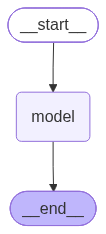

In [4]:
from langchain.agents import create_agent

from dotenv import load_dotenv
# 从.env文件中加载环境变量# override=True 确保.env文件优先
load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

agent = create_agent("deepseek:deepseek-v4-flash")#实际使用的是ChatDeepSeek()方法
print(type(agent))# 底层需要langGraphs库的支持

from IPython.display import display,Image

display(Image(agent.get_graph().draw_mermaid_png()))

## 2.2 传入模型实例

<class 'langgraph.graph.state.CompiledStateGraph'>


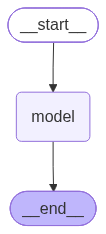

In [5]:
import os
from langchain_openai import ChatOpenAI

load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
OPENAI_API_BASE = os.environ["OPENAI_API_BASE"]  # 与本项目 .env 中的名称一致



model= ChatOpenAI(
    model="gpt-6-luna",  # 当前配置已验证可用；原 gpt-5.5 返回模型权限 403
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE,
)

agent = create_agent(model=model)  # 传入的是 ChatOpenAI 实例
print(type(agent))# 底层需要langGraphs库的支持

from IPython.display import display,Image

display(Image(agent.get_graph().draw_mermaid_png()))

## 2.3 两种方式怎么选

传入字符串时，`create_agent` 在内部调用 `init_chat_model(字符串)` 创建模型（源码：`if isinstance(model, str): model = init_chat_model(model)`）。这样创建的模型**只能用默认参数**：密钥从环境变量读取，`base_url`、`temperature`、`extra_body` 这些都没法设置。

| | 传入字符串 | 传入模型实例 |
|---|---|---|
| 写法 | `"deepseek:deepseek-v4-flash"`（`提供商:模型名`） | `ChatDeepSeek(...)`、`ChatOpenAI(...)`、`init_chat_model(...)` |
| 谁创建模型 | `create_agent` 内部调用 `init_chat_model` | 你自己 |
| 能否设置参数 | 不能，全部用默认值 | 能，比如 `base_url`、`temperature`、`extra_body` |
| 适合 | 快速试验 | 正式使用，或者需要自定义参数 |

对比一下两种方式得到的模型（不请求模型）：

In [8]:
from langchain.chat_models import init_chat_model
from langchain_deepseek import ChatDeepSeek

# 2.1 的写法：create_agent 内部就是这样创建模型的，参数全部是默认值
string_model = init_chat_model("deepseek:deepseek-v4-flash")
print("字符串方式:", type(string_model).__name__, "| base_url:", string_model.api_base, "| extra_body:", string_model.extra_body)

# 自己创建实例：可以关闭思考模式，配置和前面几章相同。本笔记后面的演示都用它
deepseek_model = ChatDeepSeek(
    model="deepseek-v4-flash",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    extra_body={"thinking": {"type": "disabled"}},
)
print("实例方式:  ", type(deepseek_model).__name__, "| base_url:", deepseek_model.api_base, "| extra_body:", deepseek_model.extra_body)

字符串方式: ChatDeepSeek | base_url: https://api.deepseek.com/v1 | extra_body: None
实例方式:   ChatDeepSeek | base_url: https://api.deepseek.com | extra_body: {'thinking': {'type': 'disabled'}}


## 2.4 agent 到底是什么（不懂 LangGraph 也能看懂）

2.1 打印出 `agent` 的类型是 LangGraph 的 `CompiledStateGraph`，画出来的图只有三个方框。这一节解释它到底是什么。

### 2.4.1 从手动调用工具说起

第五章 `01-Tools_usage.ipynb` 的 1.4 节手动完成过一次工具调用：模型发起工具调用 → 我们执行工具 → 把结果交回模型 → 模型给出答案。如果模型需要连续调用好几次工具，就得写成一个循环：

```python
messages = [HumanMessage("北京现在天气怎么样？")]
while True:
    ai_msg = model_with_tools.invoke(messages)        # ① 调用模型
    messages.append(ai_msg)
    if not ai_msg.tool_calls:                          # ② 没有工具调用：得到最终答案，结束
        break
    for tool_call in ai_msg.tool_calls:                # ③ 有工具调用：执行工具，结果放回消息列表，再回到 ①
        messages.append(tools_by_name[tool_call["name"]].invoke(tool_call))
```

**Agent 就是把这个循环封装好的对象。** 你只需要提供模型、工具和问题，它自己决定调用哪些工具、调用几次，直到得出答案。

### 2.4.2 LangGraph 用"图"来描述这个循环

`create_agent` 没有直接写 `while` 循环，而是用 LangGraph 把循环画成了一张"图"。看懂这张图只需要三个概念：

| 概念 | 含义 | 在 Agent 里对应什么 |
|---|---|---|
| 状态（State） | 在各个步骤之间传递的一份数据，每一步都可以读取和更新它 | 主要是 `messages`，也就是整个对话的消息列表 |
| 节点（Node） | 一个步骤，本质上是一个函数 | `model`：调用大模型；`tools`：执行工具 |
| 边（Edge） | 决定下一步去哪个节点 | 模型的回复里有 `tool_calls` 就去 `tools`，没有就结束 |

另外，`__start__` 和 `__end__` 分别是入口和出口；`CompiledStateGraph` 里的"编译"（Compiled）指的是图已经组装好、可以运行了。它和第六章讲的链一样也是 Runnable，所以同样用 `invoke` 调用。

把上面的循环代码和图对应起来：

| 循环代码 | 图 |
|---|---|
| ① 调用模型 | `model` 节点 |
| ② 没有工具调用就结束 | `model` → `__end__` 的边 |
| ③ 执行工具，再回到 ① | `model` → `tools` 的边，以及 `tools` → `model` 的边 |

2.1、2.2 没有传入工具，所以图里只有 `model` 一个节点：调用一次模型就结束，和直接调用模型差不多。传入工具后，图里会多出 `tools` 节点和一个循环（虚线表示"按条件选择"的边）：

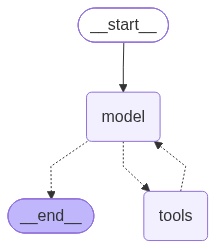

In [10]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """查询指定城市的实时天气"""
    return f"{city}：晴，22 摄氏度，东南风 2 级"   # 演示用的固定结果

weather_agent = create_agent(model=deepseek_model, tools=[get_weather])

display(Image(weather_agent.get_graph().draw_mermaid_png()))

### 2.4.3 运行一次看看

`invoke` 的输入是一个字典，`messages` 里放用户的问题；返回的是**运行结束时的状态**，其中 `messages` 记录了整个过程。下面按消息类型标出每条消息是哪一步产生的（会请求两次模型）：

In [8]:
result = weather_agent.invoke({"messages": [{"role": "user", "content": "北京现在天气怎么样？"}]})

print("返回值的键:", list(result))
source = {"HumanMessage": "输入      ", "AIMessage": "model 节点", "ToolMessage": "tools 节点"}
for msg in result["messages"]:
    body = msg.tool_calls if getattr(msg, "tool_calls", None) else msg.content
    print(f"[{source[type(msg).__name__]}] {type(msg).__name__}: {body}")

返回值的键: ['messages']
[输入      ] HumanMessage: 北京现在天气怎么样？
[model 节点] AIMessage: [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_MQ5U6A977iv5RZVUzru28550', 'type': 'tool_call'}]
[tools 节点] ToolMessage: 北京：晴，22 摄氏度，东南风 2 级
[model 节点] AIMessage: 北京现在的天气情况如下：

- **天气**：晴 ☀️
- **气温**：22 摄氏度
- **风力**：东南风 2 级

天气不错，晴朗且温度舒适，很适合外出活动。不过早晚温差可能较大，建议随身带件薄外套。需要查询其他城市或未来几天的天气吗？


对照上面的图来读这四条消息：

1. 用户的问题进入状态的 `messages`，从 `__start__` 走到 `model` 节点
2. `model` 节点调用模型。模型的回复里有 `tool_calls`（要查北京的天气），于是沿着边走到 `tools` 节点
3. `tools` 节点执行 `get_weather`，把结果作为 `ToolMessage` 追加到 `messages`，再回到 `model` 节点
4. 模型看到工具结果，给出最终回答。这次回复里没有 `tool_calls`，于是走向 `__end__`，运行结束

整个过程调用了两次模型、一次工具，都是 Agent 自己完成的，这就是 2.4.1 里的那个循环。

## 2.5 create_agent 的常用参数

### 2.5.1 参数总览

| 参数 | 作用 | 常用程度 |
|---|---|---|
| `model` | Agent 使用的模型，字符串或模型实例 | 必填，见 2.1–2.3 |
| `tools` | Agent 可以调用的工具 | 常用，见 2.5.2 |
| `system_prompt` | 系统提示词，规定 Agent 的角色和行为 | 常用，见 2.5.3 |
| `response_format` | 让 Agent 的最终结果是结构化数据 | 常用，见 2.5.4 |
| `checkpointer` | 保存对话状态，实现多轮对话记忆 | 常用，见 2.5.5 |
| `middleware` | 中间件：在调用模型、调用工具的前后插入自定义逻辑 | 进阶 |
| `store` | 长期记忆：跨对话、跨用户保存数据 | 进阶 |
| `state_schema` | 在 `messages` 之外，给状态增加自定义字段 | 进阶 |
| `context_schema` | 运行时传入的上下文，比如当前用户的 id | 进阶 |
| `interrupt_before` / `interrupt_after` | 在某个节点之前或之后暂停，等待人工确认 | 进阶 |
| `debug` | 打印每一步的执行细节，调试时用 | 调试用 |
| `name` | 给 Agent 起名，多个 Agent 协作时用 | 进阶 |
| `cache` / `transformers` | 缓存节点结果 / 自定义流式输出的处理 | 少用 |

下面用代码介绍常用的四个：`tools`、`system_prompt`、`response_format`、`checkpointer`。

### 2.5.2 tools：Agent 可以调用的工具

`tools` 是一个列表，第五章介绍的几种工具都可以放进去：`@tool` 定义的工具、普通函数（会被自动转换成工具）、厂商内置工具的字典。

- 不传 `tools`（或传空列表）时，图里没有 `tools` 节点，就是 2.1 那张图
- 传了 `tools` 时，所有工具都由 `tools` 节点统一执行。模型一次返回多个 tool_call 时，它会把这些工具都执行掉

看看 `tools` 节点里实际放了什么（不请求模型）：

In [11]:
def get_time(city: str) -> str:
    """查询指定城市的当前时间"""
    return f"{city}现在是下午 3 点"   # 普通函数，没有加 @tool

two_tools_agent = create_agent(model=deepseek_model, tools=[get_weather, get_time])

tool_node = two_tools_agent.nodes["tools"].bound   # 图里的 tools 节点
print("tools 节点的类型:", type(tool_node).__name__)
for name, t in tool_node.tools_by_name.items():
    print(f"  {name}: {type(t).__name__}")

tools 节点的类型: ToolNode
  get_weather: StructuredTool
  get_time: StructuredTool


In [15]:
for node in two_tools_agent.nodes.items():
    print(node)
print(two_tools_agent.nodes)

('__start__', <langgraph.pregel._read.PregelNode object at 0x1157f0550>)
('model', <langgraph.pregel._read.PregelNode object at 0x1157f07d0>)
('tools', <langgraph.pregel._read.PregelNode object at 0x1157f0a90>)
{'__start__': <langgraph.pregel._read.PregelNode object at 0x1157f0550>, 'model': <langgraph.pregel._read.PregelNode object at 0x1157f07d0>, 'tools': <langgraph.pregel._read.PregelNode object at 0x1157f0a90>}


普通函数 `get_time` 也被转换成了 `StructuredTool`，和 `@tool` 定义的工具一样。工具的写法和注意事项见第五章。

### 2.5.3 system_prompt：系统提示词

`system_prompt` 规定 Agent 的角色、行为规则和回答风格，可以传字符串，也可以传 `SystemMessage`。每次调用模型时，它会被放在消息列表的最前面。

下面给天气 Agent 加一条规则："只回答天气相关的问题"，再问它一个无关的问题（会请求一次模型）：

In [10]:
weather_assistant = create_agent(
    model=deepseek_model,
    tools=[get_weather],
    system_prompt="你是一个天气助手。只回答和天气相关的问题；遇到其他问题，礼貌拒绝并说明你能做什么。回答不超过 50 字。",
)

result = weather_assistant.invoke({"messages": [{"role": "user", "content": "帮我写一首关于秋天的诗"}]})
print([type(msg).__name__ for msg in result["messages"]])
print(result["messages"][-1].content)

['HumanMessage', 'AIMessage']
抱歉，我只能回答天气相关问题，比如查询城市实时天气。需要帮忙吗？


Agent 按系统提示词拒绝了写诗的请求，也没有调用工具。

注意返回的 `messages` 里只有 `HumanMessage` 和 `AIMessage`，**没有 `SystemMessage`**：系统提示词并不保存在状态里，而是在每次调用模型时临时加到消息列表的最前面。

### 2.5.4 response_format：结构化的最终结果

第六章用 `with_structured_output` 让模型直接返回 Pydantic 对象。Agent 里对应的参数是 `response_format`：Agent 照常调用工具，最后把答案整理成指定的结构，放在返回值的 `structured_response` 里。

`response_format` 可以直接传 Pydantic 类，这时 `create_agent` 会根据模型能力**自动选择**两种策略之一：

| 策略 | 做法 | 什么时候用 |
|---|---|---|
| `ProviderStrategy` | 使用厂商原生的结构化输出（如 OpenAI 的 `json_schema`，第六章的方式） | 模型档案（`model.profile`）里声明支持结构化输出时 |
| `ToolStrategy` | 把 schema 当成一个工具，让模型"调用"它来提交答案 | 其他情况 |

先直接传 Pydantic 类试试（会请求一次模型）：

In [11]:
from pydantic import BaseModel, Field

class WeatherReport(BaseModel):
    """天气播报"""
    city: str = Field(description="城市")
    weather: str = Field(description="天气状况")
    temperature: int = Field(description="气温，单位摄氏度")
    advice: str = Field(description="一句出行建议")

print("DeepSeek 的模型档案声明支持结构化输出:", deepseek_model.profile.get("structured_output"))

auto_agent = create_agent(model=deepseek_model, tools=[get_weather], response_format=WeatherReport)
try:
    auto_agent.invoke({"messages": [{"role": "user", "content": "北京现在天气怎么样？"}]})
except Exception as e:
    print(type(e).__name__, "->", e)

DeepSeek 的模型档案声明支持结构化输出: True


OpenAIInvalidRequestError -> Error code: 400 - {'error': {'message': 'This response_format type is unavailable now (request_id: 0aa57123-451b-496a-b382-a490b4e97693)', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


报错了。DeepSeek 的模型档案声明支持结构化输出，所以 `create_agent` 自动选择了 `ProviderStrategy`，发送了 `json_schema` 类型的 `response_format`；但 DeepSeek 的接口并不支持这种格式（第六章 `02-Pydantic的高级特性.ipynb` 的 1.7.1 也提到过），于是返回了 400 错误。

解决办法是用 `ToolStrategy` 显式指定策略（会请求两次模型）：

In [12]:
from langchain.agents.structured_output import ToolStrategy

report_agent = create_agent(
    model=deepseek_model,
    tools=[get_weather],
    response_format=ToolStrategy(WeatherReport),   # 显式使用 ToolStrategy
)
result = report_agent.invoke({"messages": [{"role": "user", "content": "北京现在天气怎么样？"}]})

for msg in result["messages"]:
    body = msg.tool_calls if getattr(msg, "tool_calls", None) else msg.content
    print(f"{type(msg).__name__:<12}", body)
print()
print("structured_response:", repr(result["structured_response"]))

HumanMessage 北京现在天气怎么样？
AIMessage    [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_SRa8xCDiNHnvjWzNwhfS9026', 'type': 'tool_call'}]
ToolMessage  北京：晴，22 摄氏度，东南风 2 级
AIMessage    [{'name': 'WeatherReport', 'args': {'city': '北京', 'weather': '晴', 'temperature': 22, 'advice': '天气晴朗，气温舒适，适合外出；早晚温差较大，建议随身带一件薄外套。'}, 'id': 'call_00_BKg8U5rEY8BqcxYsBxNK0068', 'type': 'tool_call'}]
ToolMessage  Returning structured response: city='北京' weather='晴' temperature=22 advice='天气晴朗，气温舒适，适合外出；早晚温差较大，建议随身带一件薄外套。'

structured_response: WeatherReport(city='北京', weather='晴', temperature=22, advice='天气晴朗，气温舒适，适合外出；早晚温差较大，建议随身带一件薄外套。')


这次多了两条消息：模型先调用 `get_weather` 拿到天气，然后"调用"了一个名叫 `WeatherReport` 的工具来提交答案，参数就是结构化的结果。

这个工具并不在 `tools` 节点里，是 `ToolStrategy` 根据 schema 生成的。Agent 收到这个调用后，用 Pydantic 解析参数、放进 `structured_response`，补上一条 `ToolMessage`，然后结束运行。

模型确实支持厂商原生的结构化输出时，自动选择的 `ProviderStrategy` 能正常工作；遇到上面这种报错，改用 `ToolStrategy` 最省事。

### 2.5.5 checkpointer：多轮对话的记忆

默认情况下，每次 `invoke` 都是一次全新的对话：Agent 不记得上一次说过什么。`checkpointer` 会在每次运行结束后保存状态（也就是消息列表），下次运行时自动接上。

- `InMemorySaver`：把状态保存在内存里，程序结束就没了，适合学习和测试
- `thread_id`：会话编号，写在 `config` 里。**同一个 `thread_id` 共享记忆，不同的 `thread_id` 互不相干**

下面分两轮对话：第 1 轮告诉 Agent 住在哪里，第 2 轮不说城市，直接问天气（共请求三次模型）：

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

memory_agent = create_agent(model=deepseek_model, tools=[get_weather], checkpointer=InMemorySaver())
config = {"configurable": {"thread_id": "user-001"}}   # 会话编号

result1 = memory_agent.invoke({"messages": [{"role": "user", "content": "我叫小明，住在北京。"}]}, config)
print("第 1 轮回复:", result1["messages"][-1].content)
print("第 1 轮结束时的消息数:", len(result1["messages"]))
print()

# 第 2 轮只传入新消息，之前的消息由 checkpointer 自动接上
result2 = memory_agent.invoke({"messages": [{"role": "user", "content": "我住的地方现在天气怎么样？"}]}, config)
for msg in result2["messages"]:
    body = msg.tool_calls if getattr(msg, "tool_calls", None) else msg.content
    print(f"{type(msg).__name__:<12}", body)
print("第 2 轮结束时的消息数:", len(result2["messages"]))

第 1 轮回复: 你好，小明！很高兴认识你。你住在北京，需要我帮你查一下北京的实时天气吗？如果需要，告诉我一声就行。
第 1 轮结束时的消息数: 2



HumanMessage 我叫小明，住在北京。
AIMessage    你好，小明！很高兴认识你。你住在北京，需要我帮你查一下北京的实时天气吗？如果需要，告诉我一声就行。
HumanMessage 我住的地方现在天气怎么样？
AIMessage    [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_GVahrJ6Hz8nIZ30b34cU1811', 'type': 'tool_call'}]
ToolMessage  北京：晴，22 摄氏度，东南风 2 级
AIMessage    小明，北京现在的天气是：

- **天气**：晴 ☀️
- **气温**：22 摄氏度
- **风力**：东南风 2 级

天气不错，挺适合出门活动。需要我帮你查别的城市或者做点别的吗？
第 2 轮结束时的消息数: 6


换一个 `thread_id`，相当于换了一个新会话（会请求一次模型）：

In [14]:
other_config = {"configurable": {"thread_id": "user-002"}}
result3 = memory_agent.invoke({"messages": [{"role": "user", "content": "我叫什么名字？"}]}, other_config)
print(result3["messages"][-1].content)

你好！我并不知道你的名字哦。😊

从我们的对话来看，你没有告诉我你的名字，我也无法获取这类个人信息。如果你愿意的话，可以直接告诉我，我就可以用你喜欢的称呼来和你交流啦！

有什么我可以帮你的吗？


几个现象：

- 第 2 轮只传入了一条新消息，返回的 `messages` 却有 6 条，前两条是第 1 轮的对话，由 `checkpointer` 自动接上
- 第 2 轮的问题里没有提到城市，Agent 从记忆里知道是北京，调用了 `get_weather(city="北京")`
- 换成 `thread_id="user-002"` 后，Agent 不知道用户叫什么，因为那是另一个会话

没有 `checkpointer` 时，要实现多轮对话，就得自己保存消息列表，每次把完整的历史传进去。

## 2.6 总结

**agent 是什么：**

1. Agent = 模型 + 工具 + 一个自动运行的循环：调用模型 → 有工具调用就执行工具、把结果交回模型 → 没有就结束
2. `create_agent` 返回的是 LangGraph 的 `CompiledStateGraph`，用"图"来描述这个循环：**状态**主要是 `messages`，**节点**是 `model` 和 `tools`，**边**根据模型回复里有没有 `tool_calls` 决定下一步
3. 它也是 Runnable：`invoke` 返回运行结束时的状态，`messages` 里记录了整个过程

**常用参数：**

| 参数 | 写法 | 注意 |
|---|---|---|
| `model` | `"deepseek:deepseek-v4-flash"` 或模型实例 | 字符串只能用默认参数，需要设置参数时传实例 |
| `tools` | `[get_weather, get_time]` | 普通函数会被自动转换成工具 |
| `system_prompt` | `"你是一个天气助手……"` | 调用模型时才加到最前面，不会出现在返回的 `messages` 里 |
| `response_format` | `ToolStrategy(WeatherReport)` | 结果在 `result["structured_response"]`；DeepSeek 要显式使用 `ToolStrategy` |
| `checkpointer` | `InMemorySaver()` | 调用时要在 `config` 里传 `thread_id` |

下一节（`02-Agent如何调用.ipynb`）会细讲调用 Agent 的各种方式。